# Voting Ensemble

**Voting Ensemble** is a machine learning technique where we use **multiple models together** and let them **vote** to make the final prediction.

Think of it like asking **3 friends** which movie is best:

* Friend 1 → Movie A
* Friend 2 → Movie A
* Friend 3 → Movie B

Since **2 out of 3** chose Movie A, you choose **Movie A**.

Machine learning models can work the same way.

---

## 1. What is Voting Ensemble?

Suppose we have three classifiers:

```text
Model 1 → SVM
Model 2 → KNN
Model 3 → Decision Tree
```

For a new data point:

```text
SVM           → Class A
KNN           → Class A
Decision Tree → Class B
```

The final prediction is:

```text
Class A
```

because **Class A received 2 votes**.

There are two main types:

1. **Hard Voting**
2. **Soft Voting**

---

# 2. Hard Voting

In **Hard Voting**, every model gives a **class prediction**.

Example:

```text
SVM           → Setosa
KNN           → Setosa
Decision Tree → Versicolor
```

Votes:

```text
Setosa      → 2 votes
Versicolor  → 1 vote
```

Final prediction:

```text
Setosa
```

### Simple definition

> **Hard Voting chooses the class that receives the most votes from the models.**


---

# 3. Soft Voting

**Soft Voting** is a little more advanced.

Instead of simply saying:

```text
SVM → Class A
```

the model gives **probabilities**:

```text
SVM:
Class A → 80%
Class B → 20%
```

Another model:

```text
KNN:
Class A → 60%
Class B → 40%
```

Another:

```text
Decision Tree:
Class A → 70%
Class B → 30%
```

Now we calculate the average probability:

```text
Class A = (80 + 60 + 70) / 3
        = 70%

Class B = (20 + 40 + 30) / 3
        = 30%
```

So the final prediction is:

```text
Class A
```

### Simple definition

> **Soft Voting uses the predicted probabilities from multiple models and chooses the class with the highest combined probability.**

---


# 5. Hard vs Soft Voting

| Hard Voting                           | Soft Voting                          |
| ------------------------------------- | ------------------------------------ |
| Uses class predictions                | Uses probabilities                   |
| Each model gets one vote              | Models contribute probability scores |
| Majority wins                         | Highest combined probability wins    |
| Simpler                               | Usually more informative             |
| Doesn't require probability estimates | Requires probability estimates       |

### Easy way to remember

**Hard Voting:**

> "Which class did you vote for?"

```text
A, A, B → A wins
```

**Soft Voting:**

> "How confident are you?"

```text
A: 90%
A: 70%
B: 60%

→ Combine probabilities → A wins
```

### Real-world analogy

Imagine three doctors diagnosing a patient.

**Hard voting:**

```text
Doctor 1 → Disease
Doctor 2 → Disease
Doctor 3 → No Disease

Final → Disease
```

**Soft voting:**

```text
Doctor 1 → Disease: 90%
Doctor 2 → Disease: 80%
Doctor 3 → Disease: 40%

Combined confidence → Disease
```

So, in one sentence:

> **Voting Ensemble combines several machine-learning models and uses their votes to produce a better final prediction. Hard voting uses the predicted classes, while soft voting uses the predicted probabilities.**


In [ ]:
import numpy as np
import seaborn as sns

In [30]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [31]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [32]:
df['species'] = encoder.fit_transform(df['species'])

In [33]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


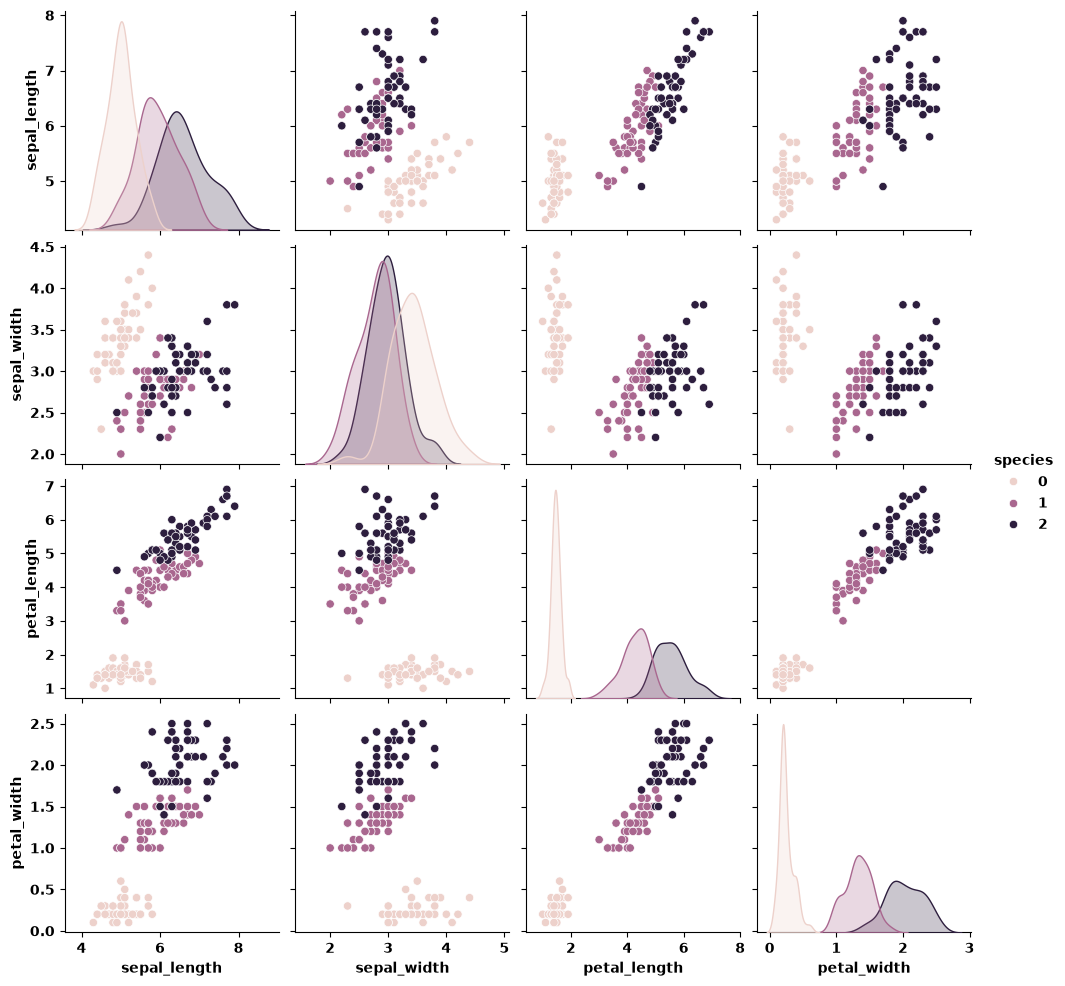

In [34]:
sns.pairplot(df, hue='species')

In [35]:
new_df = df[df['species'] != 0][['sepal_length', 'sepal_width', 'species']]

In [36]:
new_df.head()

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [37]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [39]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [40]:
estimators = [('lr', clf1), ('rf', clf2), ('knn', clf3)]

In [41]:
for estimator in estimators:
    x = cross_val_score(estimator[1], X,y, cv=10, scoring='accuracy')
    print(estimator[0], np.round(np.mean(x),2))

lr 0.81
rf 0.71
knn 0.76


In [42]:
from sklearn.ensemble import VotingClassifier

### Hard Voting

In [43]:
vc = VotingClassifier(estimators=estimators)
x = cross_val_score(vc, X,y,cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


### Soft Voting

In [44]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc1, X,y,cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


### Weighted Voting

In [45]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i,j,k])
            x = cross_val_score(vc, X,y,cv=10, scoring='accuracy')
            print("for i={}, j={}, k{}".format(i,j,k),np.round(np.mean(x),2))


for i=1, j=1, k1 0.76
for i=1, j=1, k2 0.77
for i=1, j=1, k3 0.75
for i=1, j=2, k1 0.77
for i=1, j=2, k2 0.75
for i=1, j=2, k3 0.76
for i=1, j=3, k1 0.73
for i=1, j=3, k2 0.74
for i=1, j=3, k3 0.75
for i=2, j=1, k1 0.77
for i=2, j=1, k2 0.77
for i=2, j=1, k3 0.77
for i=2, j=2, k1 0.75
for i=2, j=2, k2 0.76
for i=2, j=2, k3 0.77
for i=2, j=3, k1 0.75
for i=2, j=3, k2 0.77
for i=2, j=3, k3 0.77
for i=3, j=1, k1 0.81
for i=3, j=1, k2 0.79
for i=3, j=1, k3 0.79
for i=3, j=2, k1 0.79
for i=3, j=2, k2 0.78
for i=3, j=2, k3 0.76
for i=3, j=3, k1 0.76
for i=3, j=3, k2 0.77
for i=3, j=3, k3 0.77


### Classifiers of Same Algorithm

In [46]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [47]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1', svm1), ('svm2', svm2), ('svm3', svm3), ('svm4', svm4), ('svm5', svm5),]

for estimator in estimators:
    x = cross_val_score(estimator[1], X,y, cv=10, scoring='accuracy')
    print(estimator[0], np.round(np.mean(x),2))


svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [48]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc1, X,y,cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.93
